# Example of registration between two images and apply it to result image

In [ ]:
from utils import *


main_path = "/home/caredda/Videos/results_Functional_imaging/P25"

#Load reference surgical window contour: this image corresponds to the optical space of reference (where you want to plot all the results)
ref_mask = (cv2.imread(main_path+"/ref_mask.png",cv2.IMREAD_GRAYSCALE)/255).astype(np.uint8)


#Load surgical window to register (adapt paths here)
dir_to_register = main_path+"/Task_based_sensory/SPM_MBLL"
mask_to_register = (cv2.imread(dir_to_register+"/mask.png",cv2.IMREAD_GRAYSCALE)/255).astype(np.uint8)
Statistics_mask =  cv2.imread(dir_to_register+"/0/SPM.png",cv2.IMREAD_GRAYSCALE)

#resize mask to register
mask_to_register = cv2.resize(mask_to_register,(ref_mask.shape[1],ref_mask.shape[0]))

#get registration transform
affine_matrix = find_registration_transform(ref_mask, mask_to_register)

#Apply affine transform
Statistics_mask = cv2.warpAffine(Statistics_mask, affine_matrix, (ref_mask.shape[1], ref_mask.shape[0]))

# Display Electrical brain stimulation map

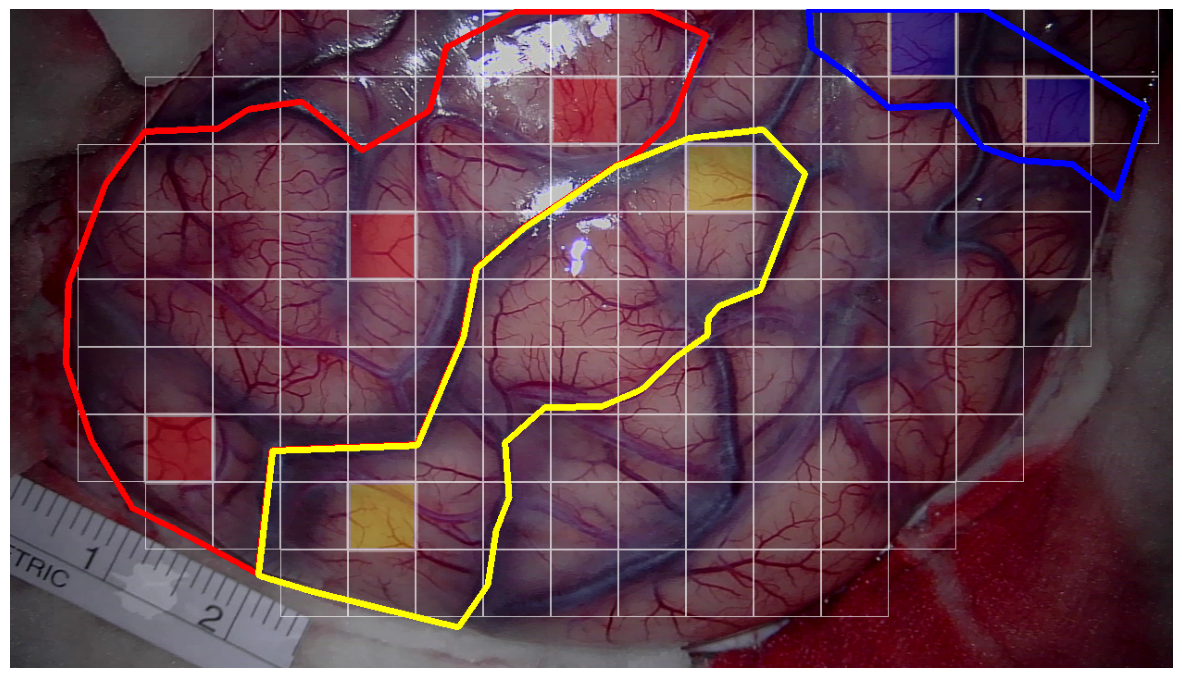

In [2]:
from utils import *

display_color_motor = (255,0,0)
display_color_sensory = (0,255,0)
display_color_language = (255,255,0)

epicenter_filename = "epicenters_article.png"
# epicenter_filename = "epicenters.png"


color_ROI = (255,255,255)
# color_ROI = -1

# main_path = "/home/caredda/Videos/results_Functional_imaging/P25"
main_path = "/home/caredda/Videos/results_Functional_imaging/P81"

#Load reference surgical window contour: this image corresponds to the optical space of reference (where you want to plot all the results)
ref_mask = (cv2.imread(main_path+"/ref_mask.png",cv2.IMREAD_GRAYSCALE)/255).astype(np.uint8)
ref_img = cv2.imread(main_path+"/ref.png")
reso_mm = np.loadtxt(main_path+"/resolution.txt")


#Get motor and sensory areas
contours = contour_brain_functions()
contours.c_motor = get_functional_mask(main_path+"/mask_activation.png", ref_img, 1, color_motor)
contours.c_sensory = get_functional_mask(main_path+"/mask_activation.png", ref_img, 1, color_sensory)
contours.c_language = get_functional_mask(main_path+"/mask_activation.png", ref_img, 1, color_language)



#Get square ROIs in reference image
diam_mm_EBS_measurement = 5
ROIs = generate_square_ROI_inside_contour(ref_mask, tile=int(diam_mm_EBS_measurement/reso_mm), min_frac=0.5)

#Create EBS map
idx_motor_epicenter = get_square_ROI_idx_EBS_epicenters(main_path+"/"+epicenter_filename, ref_img, color_motor, ROIs)
idx_sensory_epicenter = get_square_ROI_idx_EBS_epicenters(main_path+"/"+epicenter_filename, ref_img, color_sensory, ROIs)
idx_langage_epicenter = get_square_ROI_idx_EBS_epicenters(main_path+"/"+epicenter_filename, ref_img, color_language, ROIs)


#EBS map display
vis = visualize_Square_ROI(ref_img, ROIs, idx_motor_epicenter, color_ROI = color_ROI, colors_function= color_motor)
vis = visualize_Square_ROI(vis, ROIs, idx_sensory_epicenter, color_ROI = color_ROI, colors_function= color_sensory)
vis = visualize_Square_ROI(vis, ROIs, idx_langage_epicenter, color_ROI = color_ROI, colors_function= color_language)

#Draw motor and sensory contours
cv2.drawContours(vis,contours.c_motor,-1,color_motor,width_cnt)
cv2.drawContours(vis,contours.c_sensory,-1,color_sensory,width_cnt)
cv2.drawContours(vis,contours.c_language,-1,color_language,width_cnt)



#Draw activation contours
c_motor = get_functional_mask(main_path+"/mask_activation.png", ref_img, 1, color_motor)
c_sensory = get_functional_mask(main_path+"/mask_activation.png", ref_img, 1, color_sensory)
c_language = get_functional_mask(main_path+"/mask_activation.png", ref_img, 1, color_language)

cv2.drawContours(vis,c_motor,-1,color_motor,6)
cv2.drawContours(vis,c_sensory,-1,color_sensory,6)
cv2.drawContours(vis,c_language,-1,color_language,6)


plt.figure(figsize=(15,15))
plt.imshow(cv2.cvtColor(vis,cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()



# Resize Images in Patient directory if needed

In [ ]:
from utils import *

#resize_all_image_for_Patient("/home/caredda/Videos/results_Functional_imaging/P83", factor_col=1, factor_row=2 )
rotate_all_image_for_Patient("/home/caredda/Videos/results_Functional_imaging/P31", cv2.ROTATE_180)

/home/caredda/Videos/results_Functional_imaging/P31_rotate/Task_based_auto/SPM_MBLL_1
/home/caredda/Videos/results_Functional_imaging/P31_rotate/Task_based_auto/SPM_MBLL_2
/home/caredda/Videos/results_Functional_imaging/P31_rotate/Task_based_auto/SPM_MBLL_3
/home/caredda/Videos/results_Functional_imaging/P31_rotate/Task_based_auto/SPM_MBLL_4


# Process task-based images and metrics:
 - sensitivity (fOptics vs square area defined by EBS)
 - specificity (fOptics vs activation contour motor + sensory defined by EBS and the neurosurgeon)
 - distance (distance bewteen fOptics to the nearest activation contours defined by EBS and the neurosurgeon)

In [1]:
from utils import *


display_color_motor = color_motor
display_color_sensory = color_sensory

#Path where data are saved
main_path ="/home/caredda/Videos/results_Functional_imaging"

#Get patient directory
array_path = get_Patient_list(main_path)

#Start with Patient 26 (only consider several tasks with 20s rest-repetitions)
array_path = array_path[6:]


#analysis type
type_analysis_array = np.array(["Task_based_auto","Task_based_induced"])


#Contrasts to calculate
target_contrasts = np.array(["HbO2", "Hb", "HbT"])

#Number of repetion of paradigm
nb_repetion_paradigm = np.arange(1,5)


#Create output directory
result_dir = main_path+"/results/"
if(os.path.isdir(result_dir)):
    shutil.rmtree(result_dir)
os.mkdir(result_dir)


for c in target_contrasts:
    #Create contrast folder
    os.mkdir(result_dir+"results_"+c)
    #Create a folder per paradigm repetition 
    for i in nb_repetion_paradigm:
        os.mkdir(result_dir+"results_"+c+"/"+str(i))
        os.mkdir(result_dir+"results_"+c+"/"+str(i)+"/mask")
        os.mkdir(result_dir+"results_"+c+"/"+str(i)+"/Z_stats")
        os.mkdir(result_dir+"results_"+c+"/"+str(i)+"/out_images")
        os.mkdir(result_dir+"results_"+c+"/"+str(i)+"/out_images_fOptics_only") 
        os.mkdir(result_dir+"results_"+c+"/"+str(i)+"/out_images_c")
        os.mkdir(result_dir+"results_"+c+"/"+str(i)+"/metrics")
        


#Threshold (automatic procedure)
Thresh = 1.15

#Resize factor
f = 1

#Electrical brain stimulation display radius
EBS_spot_radius = 7

#EBS probe diameter in mm
diam_mm_EBS_measurement = 5
severity_EBS_compa = 0.25 #At least 25% of the EBS square need to be fill to considered to square ROI as activated
min_area_mm2 = np.pi*(diam_mm_EBS_measurement/2)**2


for i in range(len(array_path)):

    #Check if required images exist
    if(not os.path.isfile(array_path[i]+"/epicenters.png") or
       not os.path.isfile(array_path[i]+"/resolution.txt") or
       not os.path.isfile(array_path[i]+"/ref.png") or
       not os.path.isfile(array_path[i]+"/ref_mask.png") or
       not os.path.isfile(array_path[i]+"/mask_activation.png")):
       continue

    #get id patient
    id_Patient = os.path.basename(array_path[i])

    #Load reference image
    ref_img = cv2.imread(array_path[i]+"/ref.png")

    #Get reference surgical window contour
    ref_mask = (cv2.imread(array_path[i]+"/ref_mask.png",cv2.IMREAD_GRAYSCALE)/255).astype(np.uint8)

    #Get image resolution
    reso_mm = np.loadtxt(array_path[i]+"/resolution.txt")


    #Get motor and sensory areas
    contours = contour_brain_functions()
    contours.c_motor = get_functional_mask(array_path[i]+"/mask_activation.png", ref_img, f, color_motor)
    contours.c_sensory = get_functional_mask(array_path[i]+"/mask_activation.png", ref_img, f, color_sensory)

    #Get epicenters
    epicenters = contour_brain_functions()
    epicenters.c_motor = get_epicenter(array_path[i]+"/epicenters.png", ref_img, f, color_motor)
    epicenters.c_sensory = get_epicenter(array_path[i]+"/epicenters.png", ref_img, f, color_sensory)

    #Get square ROIs in reference image
    ROIs = generate_square_ROI_inside_contour(ref_mask, tile=int(diam_mm_EBS_measurement/reso_mm), min_frac=0.5)

    #Activity threshold (more than half of a square ROI has to be activated)
    Thresh_activity = int(severity_EBS_compa*int(diam_mm_EBS_measurement/reso_mm)**2)


    #Create EBS map
    idx_motor_epicenter = get_square_ROI_idx_EBS_epicenters(array_path[i]+"/epicenters.png", ref_img, color_motor, ROIs)
    idx_sensory_epicenter = get_square_ROI_idx_EBS_epicenters(array_path[i]+"/epicenters.png", ref_img, color_sensory, ROIs)
    EBS_map, EBS_map_motor, EBS_map_sensory  = create_EBS_maps(ref_img, ROIs, idx_motor_epicenter, idx_sensory_epicenter)



    #Loop over analyses (autonomous tb, induced tb, sensory)
    for i_analysis, type_analysis in enumerate(type_analysis_array):
        
        #Get analysis path
        _analysis_path = array_path[i]+"/"+type_analysis

        if not os.path.exists(_analysis_path):
            continue     
        analysis_name = os.path.basename(_analysis_path)

        #Loop over nb of paradigm
        for nb_rep in nb_repetion_paradigm:

            #Set path that contains SPM results
            path = _analysis_path+"/SPM_MBLL_"+str(nb_rep)
            if not os.path.exists(path):
                continue

            for i_c in range(target_contrasts.shape[0]):

                #Get functional images
                out, mask, SPM_mask, auto_mask, Z_stats = get_functional_img_task_based(path, i_c, Thresh, f, ref_img, ref_mask, min_area_mm2, reso_mm)

                #Write stats masks
                cv2.imwrite(result_dir+"results_"+target_contrasts[i_c]+"/"+str(nb_rep)+"/mask/SPM_"+id_Patient+".png",SPM_mask)
                cv2.imwrite(result_dir+"results_"+target_contrasts[i_c]+"/"+str(nb_rep)+"/mask/Auto_"+id_Patient+".png",auto_mask)
                np.savetxt(result_dir+"results_"+target_contrasts[i_c]+"/"+str(nb_rep)+"/Z_stats/"+id_Patient+".txt",Z_stats)


                # Draw motor and sensory areas
                if len(contours.c_motor) > 0 or len(contours.c_sensory) > 0:

                    #write result image
                    cv2.imwrite(result_dir+"results_"+target_contrasts[i_c]+"/"+str(nb_rep)+"/out_images_fOptics_only/"+id_Patient+"_"+analysis_name+".png",out)

                    

                    #Draw EBS square ROI
                    # idx_function = np.append(idx_motor_epicenter,idx_sensory_epicenter)
                    out =  visualize_Square_ROI(out, ROIs, idx_motor_epicenter.astype(int),colors_function=display_color_motor)
                    out =  visualize_Square_ROI(out, ROIs, idx_sensory_epicenter.astype(int),colors_function=display_color_sensory)
                    
                    cv2.imwrite(result_dir+"results_"+target_contrasts[i_c]+"/"+str(nb_rep)+"/out_images/"+id_Patient+"_"+analysis_name+".png",out)

                    #Draw motor and sensory contours
                    cv2.drawContours(out,contours.c_motor,-1,color_motor,width_cnt)
                    cv2.drawContours(out,contours.c_sensory,-1,color_sensory,width_cnt)

                    #Write images
                    cv2.imwrite(result_dir+"results_"+target_contrasts[i_c]+"/"+str(nb_rep)+"/out_images_c/"+id_Patient+"_"+analysis_name+".png",out)

                    
                else:
                    continue


                
                

                # Calculate sensitivity specificity metrics using epicenters HbO2
                m_auto =  get_sensitivity_specificity_epicenters(get_square_ROI_idx_functional_areas(auto_mask, ROIs, Thresh_activity),
                                                            EBS_map, EBS_map_motor, EBS_map_sensory)
                m = get_sensitivity_specificity_contours(auto_mask,mask, contours)
                m_auto.Specificity = m.Specificity
                m_auto.Patient_id = id_Patient
                m_auto.analysis_type = i_analysis+1


                m_SPM =  get_sensitivity_specificity_epicenters(get_square_ROI_idx_functional_areas(SPM_mask, ROIs, Thresh_activity),
                                                            EBS_map, EBS_map_motor, EBS_map_sensory)
                m = get_sensitivity_specificity_contours(SPM_mask,mask, contours)
                m_SPM.Specificity = m.Specificity
                m_SPM.Patient_id = id_Patient
                m_SPM.analysis_type = i_analysis+1


                #Calculate minimum distance between EBS measurements and fOptics
                dist_auto = Distance_metrics()
                dist_auto.mean_dist_motor, dist_auto.tot_motor_areas  =  get_mean_std_distance_to_EBS2(ROIs, idx_motor_epicenter, auto_mask, reso_mm, Thresh_activity, contours.c_motor)
                dist_auto.mean_practical_sensi_motor = get_practical_sensitivity(dist_auto.tot_motor_areas, len(epicenters.c_motor))

                dist_auto.mean_dist_sensory, dist_auto.tot_sensory_areas =  get_mean_std_distance_to_EBS2(ROIs, idx_sensory_epicenter, auto_mask, reso_mm, Thresh_activity, contours.c_sensory)
                dist_auto.mean_practical_sensi_sensory = get_practical_sensitivity(dist_auto.tot_sensory_areas, len(epicenters.c_sensory))

                dist_auto.Patient_id = id_Patient
                dist_auto.analysis_type = i_analysis+1


                dist_SPM = Distance_metrics()
                dist_SPM.mean_dist_motor, dist_SPM.tot_motor_areas =  get_mean_std_distance_to_EBS2(ROIs, idx_motor_epicenter, SPM_mask, reso_mm, Thresh_activity, contours.c_motor)
                dist_SPM.mean_practical_sensi_motor = get_practical_sensitivity(dist_SPM.tot_motor_areas, len(epicenters.c_motor))
                
                dist_SPM.mean_dist_sensory, dist_SPM.tot_sensory_areas =  get_mean_std_distance_to_EBS2(ROIs, idx_sensory_epicenter, SPM_mask, reso_mm, Thresh_activity, contours.c_sensory)
                dist_SPM.mean_practical_sensi_sensory = get_practical_sensitivity(dist_SPM.tot_sensory_areas, len(epicenters.c_sensory))

                #Create json for the patient
                create_json_patient(result_dir+"results_"+target_contrasts[i_c]+"/"+str(nb_rep)+"/metrics/"+id_Patient+"_"+analysis_name+".json",
                                    m_auto, m_SPM, dist_auto, dist_SPM,
                                     len(epicenters.c_motor), len(epicenters.c_sensory) )
 

/home/caredda/DVP/C++/imagerie_fonctionnelle_cerveau/git/intraoperative-functional-brain-mapping/Python/utils.py:905: RuntimeWarning: invalid value encountered in ulong_scalars
  results.Sensitiviy_sensory = TP_sensory.sum() /  (TP_sensory.sum() + FN_sensory.sum())
/home/caredda/DVP/C++/imagerie_fonctionnelle_cerveau/git/intraoperative-functional-brain-mapping/Python/utils.py:900: RuntimeWarning: invalid value encountered in ulong_scalars
  results.Sensitiviy_motor = TP_motor.sum() /  (TP_motor.sum() + FN_motor.sum())


# Create metrics tables

- TODO: split per paradigm time 20-20 and 30-30 (P23, P24, P25)

In [9]:
from utils import *


#Path where data are saved
main_path ="/home/caredda/Videos/results_Functional_imaging"

#Get patient directory
array_path = get_Patient_list(main_path)


#Paradigm 20-20 s
array_path = array_path[6:]
paradigm = "paradigm_20s"


# #Paradigm 30-30 s
# array_path = array_path[0:6]
# paradigm = "paradigm_30s"


#analysis type
type_analysis_array = np.array(["Task_based_auto","Task_based_induced"])


#Contrasts to calculate
target_contrasts = np.array(["HbO2", "Hb", "HbT"])

#Number of repetion of paradigm
nb_repetion_paradigm = np.arange(1,5)

#Loop over contrasts
for c in target_contrasts:
    #Nb de repetition 
    for n_rep in nb_repetion_paradigm:
        #Loop over analyses (autonomous tb, induced tb, sensory)
        for type_analysis in type_analysis_array:
            
            #Init metrics
            dist_auto = Distance_metrics()
            dist_auto.init_list()
            dist_SPM = Distance_metrics()
            dist_SPM.init_list()
            metrics_auto = Sensitivity_specificity_metrics()
            metrics_auto.init_list()
            metrics_SPM = Sensitivity_specificity_metrics()
            metrics_SPM.init_list()

       
            #Loop over patients
            for p in array_path:

                #json file path
                file = main_path+"/results/results_"+c+"/"+str(n_rep)+"/metrics/"+os.path.basename(p)+"_"+type_analysis+".json"
                
                if not os.path.exists(file):
                    continue


                #read json and store results in objects
                df = pd.read_json(file, orient="records")

                metrics_auto.Sensitiviy_motor.append(df["Sensitivity motor auto"][0])
                metrics_auto.TP_motor.append(df["TP_motor_auto"][0])
                metrics_auto.TP_sensory.append(df["TP_sensory_auto"][0])
                metrics_auto.Sensitiviy_sensory.append(df["Sensitivity sensory auto"][0])
                metrics_auto.Specificity.append(df["Specificity auto"][0])
                metrics_auto.nb_EBS_motor.append(df["nb EBS motor"][0])
                metrics_auto.nb_EBS_sensory.append(df["nb EBS sensory"][0])
                
                
                metrics_SPM.Sensitiviy_motor.append(df["Sensitivity motor SPM"][0])
                metrics_SPM.TP_motor.append(df["TP_motor_SPM"][0])
                metrics_SPM.TP_sensory.append(df["TP_sensory_SPM"][0])
                metrics_SPM.Sensitiviy_sensory.append(df["Sensitivity sensory SPM"][0])
                metrics_SPM.Specificity.append(df["Specificity SPM"][0])
                
                dist_auto.Patient_id.append(df['Patient ID'][0])
                
                dist_auto.mean_dist_motor.append(df["Mean Dist motor auto (mm)"][0])
                dist_auto.mean_dist_sensory.append(df["Mean Dist sensory auto (mm)"][0])
                dist_auto.mean_practical_sensi_motor.append(df["Mean practical sensi motor auto"][0])
                dist_auto.mean_practical_sensi_sensory.append(df["Mean practical sensi sensory auto"][0])
                dist_auto.tot_motor_areas.append(df['nb detected motor auto'][0])
                dist_auto.tot_sensory_areas.append(df['nb detected sensory auto'][0])
                

                dist_SPM.mean_dist_motor.append(df["Mean Dist motor SPM (mm)"][0])
                dist_SPM.mean_dist_sensory.append(df["Mean Dist sensory SPM (mm)"][0])
                dist_SPM.mean_practical_sensi_motor.append(df["Mean practical sensi motor SPM"][0])
                dist_SPM.mean_practical_sensi_sensory.append(df["Mean practical sensi sensory SPM"][0])
                dist_SPM.tot_motor_areas.append(df['nb detected motor SPM'][0])
                dist_SPM.tot_sensory_areas.append(df['nb detected sensory SPM'][0])


 
            #Convert into np array 
            dist_SPM.convert_to_np_arrays()
            dist_auto.convert_to_np_arrays()
            metrics_SPM.convert_to_np_arrays()
            metrics_auto.convert_to_np_arrays()

            # print(c,n_rep,type_analysis)
            # print("tot motor non detected",dist_auto.tot_motor_areas)
            # print("tot motor EBS",metrics_auto.nb_EBS_motor)



            # #Replace 0 values in dist array with np.nan
            # dist_SPM.convert_0_to_nan()
            # dist_auto.convert_0_to_nan()


            #Write xlsx file
            file = main_path+"/results/results_"+c+"/"+str(n_rep)+"/metrics_"+type_analysis+"_"+paradigm+".xlsx"
            write_metric_results_Latex(file, metrics_auto, metrics_SPM,
                                       dist_auto, dist_SPM)
            
            # file = main_path+"/results/results_"+c+"/"+str(n_rep)+"/metrics_"+type_analysis+"_"+paradigm+"_data.xlsx"
            # write_metric_results2(file, metrics_auto, metrics_SPM, dist_auto, dist_SPM)



    
    #Store only mean+/std values in a xlsx file
    for type_analysis in type_analysis_array:
        rows = []
        #Nb de repetition 
        for n_rep in nb_repetion_paradigm:

            file = main_path+"/results/results_"+c+"/"+str(n_rep)+"/metrics_"+type_analysis+"_"+paradigm+".xlsx"
            df = pd.read_excel(file).dropna(how="all")
            row = df.iloc[-2].copy()
            row["Paradigm repetition"] = n_rep
            rows.append(row)
            row = df.iloc[-1].copy()
            row["Paradigm repetition"] = n_rep
            rows.append(row)
            


        result = pd.DataFrame(rows)
        file = main_path+"/results/results_"+c+"/metrics_"+type_analysis+"_"+paradigm+".xlsx"
        result.to_excel(file, index=False)



        
            

# Stats 20s

In [ ]:
from utils import *
import scikit_posthocs as sp
from scipy.stats import kruskal, f_oneway, ttest_ind

main_path = "/home/caredda/Videos/results_Functional_imaging/"

#Constrasts
target_contrasts = np.array(["HbO2", "Hb", "HbT"])

#Number of repetion of paradigm
nb_repetion_paradigm = np.arange(1,5)

#analysis type
type_analysis_array = np.array(["Task_based_auto","Task_based_induced"])
type_analysis = "Task_based_auto"

#Paradigm
paradigm = "paradigm_20s"
# paradigm = "paradigm_30s"


keys = ["Sensitivity motor auto","Sensitivity motor SPM","Sensitivity sensory auto","Sensitivity sensory SPM",
        "Specificity auto","Specificity SPM",
        "Dist motor auto (mm)","Dist motor SPM (mm)","Dist sensory auto (mm)",
        "Dist sensory SPM (mm)"]
# keys = ["Dist motor SPM (mm)"]

for c in target_contrasts:
    for key in keys:
        samples = []
        for n_rep in nb_repetion_paradigm:
            
            file = main_path+"results/results_"+c+"/"+str(n_rep)+"/metrics_"+type_analysis+"_"+paradigm+"_data.xlsx"
            if not os.path.exists(file):
                continue

            data = pd.read_excel(file, usecols=[key])[key].tolist()
            data = [x for x in data if not np.isnan(x)]
            samples.append(data)

            # #Test normality
            # stat, p = stats.shapiro(data)

            # if p > 0.05:
            #     print(c, n_rep,key,"  -> normality NOT rejected (looks normal)")
            # else:
            #     print(c, n_rep,key,"  -> normality rejected (deviates from normal)")

        if len(samples)==0:
            continue


        # Normality is rejected so I use non-parametric Kruskal–Wallis 
        # to compare the central tendency of several groups without assuming normality
        # using ranks of the data
        # print(samples)
        stat, p = kruskal(*samples)
        # print("Kruskal", p)
        
        # stat, p_anova = f_oneway(*samples)
        # print("ANOVA", p_anova)
        
        if not np.isnan(p) and p<0.05:
            print(c,key, p)
            print(key, "kruskal pvalue",p)
            groups = []
            for d in samples:
                groups.append(np.array(d))

            # Dunn test with Benjamini–Hochberg FDR correction (or 'bonferroni')
            p_adjust_method = 'fdr_bh'  # or 'bonferroni', 'holm', etc.

            dunn_results = sp.posthoc_dunn(groups, p_adjust=p_adjust_method)
            print(dunn_results)

HbO2 Specificity SPM 0.008364291192717617
Specificity SPM kruskal pvalue 0.008364291192717617
          1         2         3         4
1  1.000000  0.280232  0.045137  0.009857
2  0.280232  1.000000  0.280232  0.079152
3  0.045137  0.280232  1.000000  0.371969
4  0.009857  0.079152  0.371969  1.000000
Hb Specificity SPM 0.009603521086374696
Specificity SPM kruskal pvalue 0.009603521086374696
          1         2         3         4
1  1.000000  0.341154  0.053403  0.012028
2  0.341154  1.000000  0.285298  0.069745
3  0.053403  0.285298  1.000000  0.372904
4  0.012028  0.069745  0.372904  1.000000
HbT Specificity SPM 0.004717144181321564
Specificity SPM kruskal pvalue 0.004717144181321564
          1         2         3         4
1  1.000000  0.447998  0.087379  0.004609
2  0.447998  1.000000  0.246579  0.022770
3  0.087379  0.246579  1.000000  0.205752
4  0.004609  0.022770  0.205752  1.000000


# Stats 20s vs 30s

In [ ]:
from utils import *
import scikit_posthocs as sp
from scipy.stats import kruskal, f_oneway, ttest_ind, mannwhitneyu

main_path = "/home/caredda/Videos/results_Functional_imaging/"

#Constrasts
target_contrasts = np.array(["HbO2", "Hb", "HbT"])

#Number of repetion of paradigm
n_rep = 1

#analysis type
type_analysis = "Task_based_auto"

#Paradigm
paradigm = "paradigm_20s"
# paradigm = "paradigm_30s"


keys = ["Sensitivity motor auto","Sensitivity motor SPM","Sensitivity sensory auto","Sensitivity sensory SPM",
        "Specificity auto","Specificity SPM",
        "Dist motor auto (mm)","Dist motor SPM (mm)","Dist sensory auto (mm)",
        "Dist sensory SPM (mm)"]
keys=["Sensitivity motor auto"]

for c in target_contrasts:
    print(c)
    for key in keys:
        samples = []
            
        file = main_path+"results/results_"+c+"/"+str(n_rep)+"/metrics_"+type_analysis+"_"+"paradigm_20s"+"_data.xlsx"
        data_20s = pd.read_excel(file, usecols=[key])[key].tolist()
        data_20s = [x for x in data_20s if not np.isnan(x)]

        file = main_path+"results/results_"+c+"/"+str(n_rep)+"/metrics_"+type_analysis+"_"+"paradigm_30s"+"_data.xlsx"
        data_30s = pd.read_excel(file, usecols=[key])[key].tolist()
        data_30s = [x for x in data_30s if not np.isnan(x)]


        groups = []
        groups.append(np.array(data_20s))
        groups.append(np.array(data_30s))
        

        s,p = mannwhitneyu(data_20s,data_30s)

        if p<0.05:        
            print(key,p)

HbO2
Sensitivity motor auto 0.5521133419366361
Hb
Sensitivity motor auto 0.33434586953914525
HbT
Sensitivity motor auto 0.8349486135404027


# Plot effect of nb of paradigms

EBS_map_motor (123,) 2
EBS_map_sensory (123,) 1
(712, 1256, 3)
(712, 1256, 3)


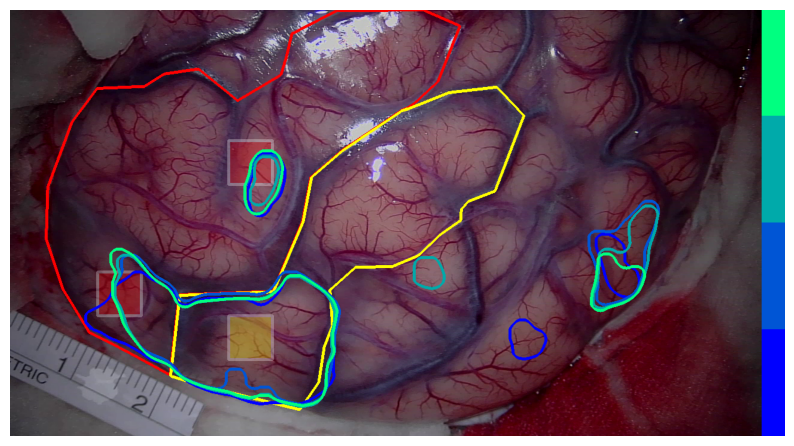

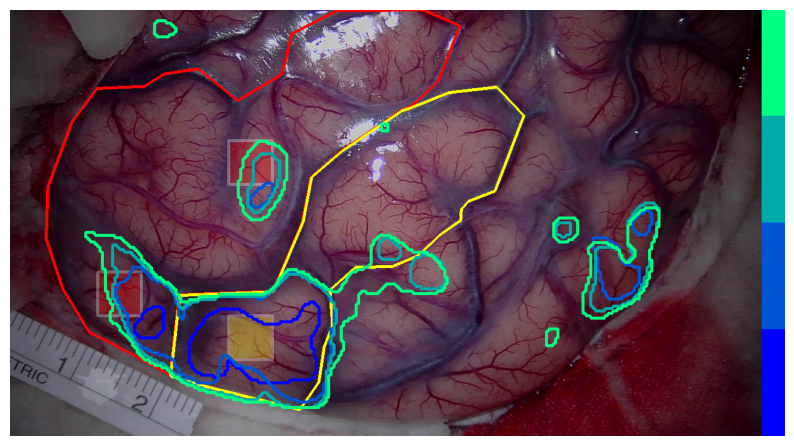

In [2]:
from utils import *


display_color_motor = color_motor
display_color_sensory = color_sensory

f = 1

#Path where data are saved
main_path ="/home/caredda/Videos/results_Functional_imaging"

#patient info
Patient_id = "P81"
patient_path = main_path+"/"+Patient_id

#Create output directory
result_dir = main_path+"/results/results_Hb/"

type_analysis = "Task_based_auto"
nb_repetion_paradigm = np.arange(1,5)

#Load reference image
ref_img = cv2.imread(patient_path+"/ref.png")
ref_mask = (cv2.imread(patient_path+"/ref_mask.png",cv2.IMREAD_GRAYSCALE)/255).astype(np.uint8)

#EBS probe diameter in mm
diam_mm_EBS_measurement = 5

#Get image resolution
reso_mm = np.loadtxt(patient_path+"/resolution.txt")


#Get motor and sensory areas
contours = contour_brain_functions()
contours.c_motor = get_functional_mask(patient_path+"/mask_activation.png", ref_img, f, color_motor)
contours.c_sensory = get_functional_mask(patient_path+"/mask_activation.png", ref_img, f, color_sensory)

#Get epicenters
epicenters = contour_brain_functions()
epicenters.c_motor = get_epicenter(patient_path+"/epicenters.png", ref_img, f, color_motor)
epicenters.c_sensory = get_epicenter(patient_path+"/epicenters.png", ref_img, f, color_sensory)

#Get square ROIs in reference image
ROIs = generate_square_ROI_inside_contour(ref_mask, tile=int(diam_mm_EBS_measurement/reso_mm), min_frac=0.5)



#Create EBS map
idx_motor_epicenter = get_square_ROI_idx_EBS_epicenters(patient_path+"/epicenters.png", ref_img, color_motor, ROIs)
idx_sensory_epicenter = get_square_ROI_idx_EBS_epicenters(patient_path+"/epicenters.png", ref_img, color_sensory, ROIs)
EBS_map, EBS_map_motor, EBS_map_sensory  = create_EBS_maps(ref_img, ROIs, idx_motor_epicenter, idx_sensory_epicenter)

print("EBS_map_motor",EBS_map_motor.shape,EBS_map_motor.sum())
print("EBS_map_sensory",EBS_map_sensory.shape,EBS_map_sensory.sum())


#Plot epicenters and eloquent cortices

 #Draw EBS square ROI
out =  visualize_Square_ROI(ref_img, ROIs, idx_motor_epicenter.astype(int),colors_function=display_color_motor)
out =  visualize_Square_ROI(out, ROIs, idx_sensory_epicenter.astype(int),colors_function=display_color_sensory)

#Draw motor and sensory contours
cv2.drawContours(out,contours.c_motor,-1,color_motor,width_cnt)
cv2.drawContours(out,contours.c_sensory,-1,color_sensory,width_cnt)

out_auto = out.copy()
out_SPM = out.copy()

print(out_auto.shape)
print(ref_img.shape)

#Create colorbar
colorbar_img, colors = create_colorbar_N_values(out_auto, 4, cv2.COLORMAP_WINTER)


#Loop over nb of paradigm
for i,nb_rep in enumerate(nb_repetion_paradigm):

    color = (int(colors[i,0]), int(colors[i,1]), int(colors[i,2]))  # Ensure integers

    #Auto
    mask = cv2.imread(result_dir+str(nb_rep)+"/mask/Auto_"+Patient_id+".png",cv2.IMREAD_GRAYSCALE)
    c, hierarchy = cv2.findContours(mask.copy(),cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    cv2.drawContours(out_auto, c, -1, color, width_cnt)



    mask = cv2.imread(result_dir+str(nb_rep)+"/mask/SPM_"+Patient_id+".png",cv2.IMREAD_GRAYSCALE)
    c, hierarchy = cv2.findContours(mask.copy(),cv2.RETR_LIST, cv2.CHAIN_APPROX_NONE)
    cv2.drawContours(out_SPM, c, -1, color, width_cnt)

_out_auto = np.zeros((out_auto.shape[0],out_auto.shape[1]+colorbar_img.shape[1],3),out_auto.dtype)
_out_auto[:,:out_auto.shape[1]] = out_auto
_out_auto[:,out_auto.shape[1]:] = colorbar_img
cv2.imwrite("/home/caredda/temp/auto_paradigm_effect.png",_out_auto)

_out_SPM = np.zeros((out_auto.shape[0],out_auto.shape[1]+colorbar_img.shape[1],3),out_auto.dtype)
_out_SPM[:,:out_SPM.shape[1]] = out_SPM
_out_SPM[:,out_SPM.shape[1]:] = colorbar_img
cv2.imwrite("/home/caredda/temp/SPM_paradigm_effect.png",_out_SPM)



plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(_out_auto,cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

plt.figure(figsize=(10,10))
plt.imshow(cv2.cvtColor(_out_SPM,cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

# Combine results

In [5]:
from utils import *

#Path where data are saved
main_path ="/home/caredda/Videos/results_Functional_imaging"


#Get patient directory
array_path = get_Patient_list(main_path)
array_path = array_path[6:]

#analysis type
type_analysis_array = np.array(["Task_based_auto","Task_based_induced"])

#Contrasts to calculate
target_contrasts = np.array(["HbO2", "Hb", "HbT"])

#read first image to get shape
ref_img = cv2.imread(array_path[0]+"/ref.png")



for c in target_contrasts:

   
   results = []


   for i in range(len(array_path)):

      #Check if required images exist
      if(not os.path.isfile(array_path[i]+"/epicenters.png") or
         not os.path.isfile(array_path[i]+"/resolution.txt") or
         not os.path.isfile(array_path[i]+"/ref.png") or
         not os.path.isfile(array_path[i]+"/ref_mask.png") or
         not os.path.isfile(array_path[i]+"/mask_activation.png")):
         continue

      #get id patient
      id_Patient = os.path.basename(array_path[i])


      #Loop over analyses (autonomous tb, induced tb, sensory)
      for type_analysis in type_analysis_array:

         

         #Loop over nb of paradigm
         for nb_rep in np.arange(4,0,-1):
               
            file = main_path+"/results/results_"+c+"/"+str(nb_rep)+"/out_images_c/"+id_Patient+"_"+type_analysis+".png"
            if not os.path.exists(file):
                  continue

            # print(id_Patient,"foud",nb_rep)
            img = cv2.imread(file)
            img = cv2.resize(img, (ref_img.shape[1],ref_img.shape[0]))
            results.append(img)
            break

   nb_col = 5
   nb_row = int(np.ceil(len(results)/nb_col))

   # print(nb_col,nb_row)

   output= 255*np.ones((nb_row*ref_img.shape[0], nb_col*ref_img.shape[1], 3), dtype=np.uint8)

   for i in range(len(results)):
      # Get nb of row and nb of cols
      id_row = int(i/nb_col)
      id_col = i%nb_col

      output[id_row*ref_img.shape[0]:(id_row+1)*ref_img.shape[0],
                        id_col*ref_img.shape[1]:(id_col+1)*ref_img.shape[1], :] = results[i]
      
   cv2.imwrite(main_path+"/results/"+c+".png",output)

# temp

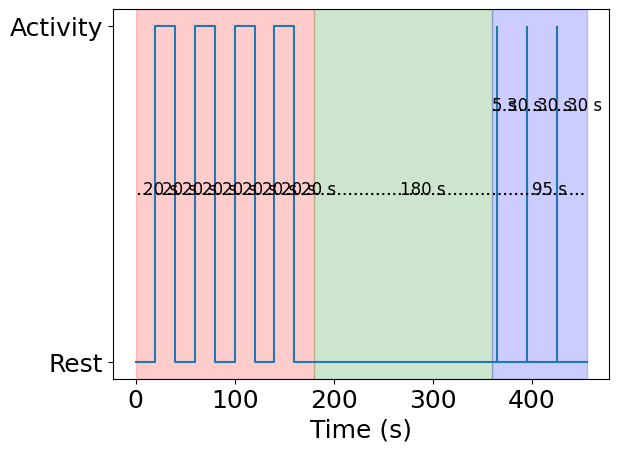

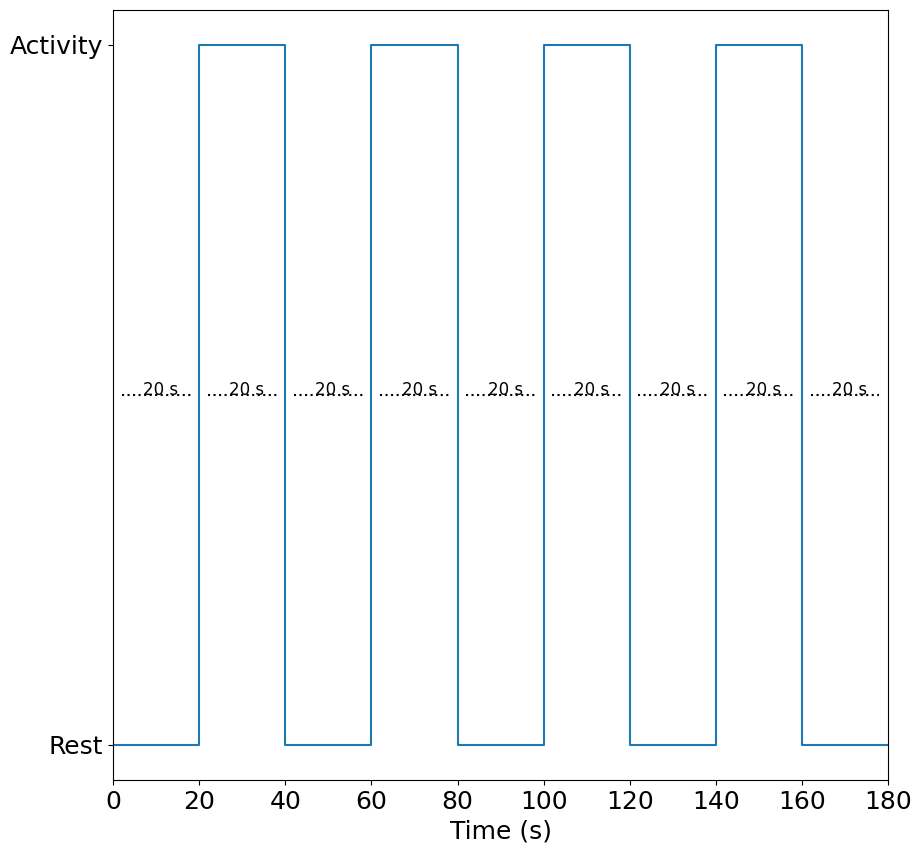

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.2
ft = 18
ft_txt =12
plt.rcParams.update({'font.size': ft})


## Activity, resting state and dirac

time = [0 ,20, 20, 40, 40, 60, 60, 80, 80, 100, 100, 120, 120, 140, 140, 160, 160, 180*2+95 ]
activity = [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0 ]


plt.close('all')
plt.plot(time,activity)
plt.axvspan(0,180,color='r',alpha = alpha)
plt.axvspan(180,2*180,color='g',alpha = alpha)
plt.axvspan(2*180,2*180+95,color='b',alpha = alpha)

#Plot dirac
plt.vlines([2*180+5,2*180+5+30,2*180+5+60],0,1)

#Plot horizontal lines
for i in range(9):
    plt.plot([2+i*20,20*(i+1)-2],[0.5,0.5],'k:')

plt.plot([2+180,2*180-2],[0.5,0.5],'k:')

plt.plot([2*180+1,2*180+95-1],[0.5,0.5],'k:')

plt.plot([2*180+1,2*180+5-1],[0.75,0.75],'k:')
plt.plot([2*180+5+1,2*180+35-1],[0.75,0.75],'k:')
plt.plot([2*180+35+1,2*180+65-1],[0.75,0.75],'k:')
plt.plot([2*180+65+1,2*180+95-1],[0.75,0.75],'k:')


#plot txt
for i in range(9):
    plt.text(2+i*20+5,0.5,"20 s",fontsize=ft_txt)

plt.text(2+180+85,0.5,"180 s",fontsize=ft_txt)
plt.text(2*180+40,0.5,"95 s",fontsize=ft_txt)

plt.text(2*180,0.75,"5 s",fontsize=ft_txt)
plt.text(2*180+5+10,0.75,"30 s",fontsize=ft_txt)
plt.text(2*180+5+30+10,0.75,"30 s",fontsize=ft_txt)
plt.text(2*180+5+60+10,0.75,"30 s",fontsize=ft_txt)


plt.xlabel("Time (s)",fontsize=ft)
plt.yticks([0,1],["Rest","Activity"],fontsize=ft)

plt.show()


## Activity 4 cycles



time = [0 ,20, 20, 40, 40, 60, 60, 80, 80, 100, 100, 120, 120, 140, 140, 160, 160, 180 ]
activity = [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0 ]


plt.close('all')
plt.figure(figsize=(10,10))
plt.plot(time,activity)
#Plot horizontal lines
for i in range(9):
    plt.plot([2+i*20,20*(i+1)-2],[0.5,0.5],'k:')


#plot txt
for i in range(9):
    plt.text(2+i*20+5,0.5,"Step "+str(i)+"\n20 s",fontsize=ft_txt)
plt.xlabel("Time (s)",fontsize=ft)
plt.yticks([0,1],["Rest","Activity"],fontsize=ft)
plt.xlim(0,180)
plt.show()



# ## Activity 1 cycle


# ft_txt = 18

# time = [0 ,30, 30, 60, 60, 90]
# activity = [0, 0, 1, 1, 0, 0]


# plt.close('all')
# plt.plot(time,activity)
# #Plot horizontal lines
# for i in range(9):
#     plt.plot([2+i*30,30*(i+1)-2],[0.5,0.5],'k:')


# #plot txt
# for i in range(3):
#     plt.text(2+i*30+10,0.5,"30 s",fontsize=ft_txt)
# plt.xlabel("Time (s)",fontsize=ft)
# plt.yticks([0,1],["Rest","Activity"],fontsize=ft)
# plt.xlim(0,90)
# plt.show()
